<a href="https://colab.research.google.com/github/bhuttazain/Operator-Scheduling-Problem/blob/main/Operator_Scheduling_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 — Heuristic Search Methods  
## Operator Scheduling Problem  
### Comparative Study using Genetic Algorithm and Tabu Search

---

## 1. Problem Statement

In this assignment, we consider the **operator scheduling problem** for a manufacturing plant. The goal is to determine a workforce schedule that **minimizes the total labor cost** while satisfying staffing requirements during both peak and non-peak production hours.

The plant employs:

- **full-time operators**, each with a different hourly wage,
- **part-time operators**, who are available only during non-peak hours at lower wage rates,
- and allows **overtime** for full-time operators during peak hours at a higher hourly rate.

The scheduling policy must ensure:

- at least **4 operators** are available during **peak hours**,
- at least **2 operators** are available during **non-peak hours**.

The objective is to find a feasible schedule with the **minimum possible total labor cost**.

---

## 2. Mathematical Formulation

### Objective Function

The operator scheduling problem is formulated as the minimization of total labor cost:

$$
f(x) = \sum_{i=1}^{m} c_i x_i + \sum_{i=1}^{m} c_i^{o} x_i^{o} + \sum_{j=1}^{n} c_j^{p} x_j^{p}
$$

where:

- $c_i$ = hourly wage of full-time operator $i$
- $c_i^{o}$ = overtime hourly wage of full-time operator $i$
- $c_j^{p}$ = hourly wage of part-time operator $j$
- $x_i$ = regular working hours assigned to full-time operator $i$ during peak hours
- $x_i^{o}$ = overtime working hours assigned to full-time operator $i$ during peak hours
- $x_j^{p}$ = working hours assigned to part-time operator $j$ during non-peak hours

---

### Constraints

#### Peak-hour staffing requirement

At least 4 operators must be scheduled during peak hours:

$$
\sum_{i=1}^{m} x_i + \sum_{i=1}^{m} x_i^{o} \geq 4
$$

#### Non-peak-hour staffing requirement

At least 2 operators must be scheduled during non-peak hours:

$$
\sum_{j=1}^{n} x_j^{p} \geq 2
$$

#### Non-negativity constraints

$$
x_i \geq 0, \quad x_i^{o} \geq 0, \quad x_j^{p} \geq 0
$$

---

## 3. Parameters

The wage rates provided in the assignment are as follows.

### Full-time operator hourly wages

$$
[30,\ 35,\ 40,\ 45,\ 50]
$$

### Overtime hourly wages

The overtime rate is 1.5 times the regular full-time wage:

$$
[45,\ 52.5,\ 60,\ 67.5,\ 75]
$$

### Part-time operator hourly wages

$$
[25,\ 27,\ 29,\ 31,\ 33]
$$

---

## 4. Decision Variables

Let:

- $x_i$ denote the number of regular working hours assigned to full-time operator $i$, for $i = 1,2,\dots,m$
- $x_i^{o}$ denote the number of overtime working hours assigned to full-time operator $i$, for $i = 1,2,\dots,m$
- $x_j^{p}$ denote the number of working hours assigned to part-time operator $j$, for $j = 1,2,\dots,n$

where:

- $m$ = number of full-time operators
- $n$ = number of part-time operators

---

## 5. Problem Type and Solution Approach

This is a **constrained cost-minimization scheduling problem**. Since the problem involves allocation decisions under staffing constraints, heuristic optimization methods are appropriate.

In this notebook, the problem will be solved using:

1. **Genetic Algorithm (GA)**
2. **Tabu Search (TS)**

These two methods will be compared in terms of solution quality, convergence behavior, and computational performance.

---

## 6. Modeling Note for Implementation

For implementation purposes, each candidate solution will represent the assigned values of:

- full-time regular hours,
- full-time overtime hours,
- and part-time working hours.

Constraint handling will be incorporated in the fitness evaluation using a penalty mechanism so that infeasible solutions are discouraged during the search process.

---

## 7. Solution Representation

To apply heuristic algorithms, each candidate solution must be encoded in a structured form.

A solution vector is defined as:

$$
X = [x_1, x_2, \dots, x_m,\; x_1^{o}, x_2^{o}, \dots, x_m^{o},\; x_1^{p}, x_2^{p}, \dots, x_n^{p}]
$$

where:

- $x_i$ = regular peak-hour allocation for full-time operator $i$
- $x_i^{o}$ = overtime allocation for full-time operator $i$
- $x_j^{p}$ = non-peak allocation for part-time operator $j$

Thus, the solution vector contains:

- $m$ variables for regular full-time hours,
- $m$ variables for overtime,
- $n$ variables for part-time hours.

Each solution represents a **complete workforce schedule**.

---

## 8. Fitness Function Design

The goal is to minimize total labor cost. Therefore, the **fitness function** is defined based on the objective function.

### Cost Function

$$
\text{Cost}(X) = \sum_{i=1}^{m} c_i x_i + \sum_{i=1}^{m} c_i^{o} x_i^{o} + \sum_{j=1}^{n} c_j^{p} x_j^{p}
$$

Since heuristic methods may generate infeasible solutions, a **penalty function** is introduced.

---

## 9. Constraint Handling

To ensure feasibility, violations of constraints are penalized.

### Peak-hour constraint violation

$$
V_{\text{peak}} = \max\left(0,\; 4 - \left(\sum_{i=1}^{m} x_i + \sum_{i=1}^{m} x_i^{o}\right)\right)
$$

### Non-peak constraint violation

$$
V_{\text{non-peak}} = \max\left(0,\; 2 - \sum_{j=1}^{n} x_j^{p}\right)
$$

---

### Penalized Fitness Function

The final fitness function is defined as:

$$
F(X) = \text{Cost}(X) + \lambda_1 V_{\text{peak}} + \lambda_2 V_{\text{non-peak}}
$$

where:

- $\lambda_1, \lambda_2$ are large penalty coefficients.

This ensures that infeasible solutions receive higher cost values and are less likely to be selected.

---

## 10. Solution Feasibility Strategy

Two mechanisms are used:

1. **Penalty-based approach**  
   - Constraint violations increase the fitness value.
   - Encourages feasible solutions during evolution.

2. **Optional repair mechanism (used later)**  
   - Adjusts solutions to satisfy minimum staffing requirements.
   - Helps improve convergence speed.

---

## 11. Encoding Considerations

- All variables are **non-negative**.
- Values may be treated as:
  - continuous (then rounded), or
  - discrete integers (preferred for scheduling interpretation).

For this study, solutions will be treated as **integer-valued** for clarity and realism.

---

## 12. Summary of Modeling Choices

| Component | Design Choice |
|---|---|
| Representation | Vector of staffing allocations |
| Objective | Minimize total labor cost |
| Constraints | Handled via penalty function |
| Variables | Integer, non-negative |
| Feasibility | Penalty + optional repair |

---


## 13. Genetic Algorithm Implementation Using PyMOO

The first heuristic method used in this study is the **Genetic Algorithm (GA)**. In this notebook, GA is implemented using the **PyMOO** library, which provides a structured framework for evolutionary optimization.

GA is suitable for the operator scheduling problem because it explores a population of candidate staffing schedules and improves them iteratively through crossover and mutation.

To improve search quality, a **multi-stage adaptive GA strategy** is used. Instead of keeping the same parameters throughout the entire run, the GA is executed in three phases:

1. **Exploration phase**: high mutation and strong crossover for global search  
2. **Balanced phase**: moderate mutation for mixed exploration and exploitation  
3. **Exploitation phase**: low mutation for local refinement  

This adaptive strategy helps the algorithm converge more reliably to high-quality solutions.

### 13.1 Chromosome Representation

Each candidate solution is represented as:

$$
X = [x_1, x_2, \dots, x_m,\; x_1^{o}, x_2^{o}, \dots, x_m^{o},\; x_1^{p}, x_2^{p}, \dots, x_n^{p}]
$$

where:

- $x_i$ = regular peak-hour allocation for full-time operator $i$
- $x_i^{o}$ = overtime allocation for full-time operator $i$
- $x_j^{p}$ = non-peak allocation for part-time operator $j$

For this problem:

- the first 5 variables represent regular full-time allocations,
- the next 5 variables represent overtime allocations,
- the last 5 variables represent part-time allocations.

Thus, each solution vector contains 15 decision variables.

### 13.2 Feasibility and Cost-Aware Normalization

In the initial GA version, infeasible or unnecessarily expensive schedules could remain in the population. To improve performance, a **cost-aware normalization step** is used.

This normalization performs the following:

- ensures that peak-hour staffing satisfies the minimum requirement,
- ensures that non-peak-hour staffing satisfies the minimum requirement,
- removes unnecessary excess allocation,
- prioritizes cheaper allocations before more expensive ones.

This makes the search more stable and helps the GA converge toward lower-cost feasible schedules.

In [3]:
!pip install pymoo -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.5 MB/s eta 0:00:00


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.pntx import SinglePointCrossover
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize

In [5]:
# Problem data from the assignment
full_time_rates = np.array([30, 35, 40, 45, 50], dtype=float)
overtime_rates = 1.5 * full_time_rates
part_time_rates = np.array([25, 27, 29, 31, 33], dtype=float)

m = len(full_time_rates)   # number of full-time operators
n = len(part_time_rates)   # number of part-time operators

# Total number of decision variables:
# [x1..x5, xo1..xo5, xp1..xp5]
n_var = m + m + n

# Integer bounds for each variable
xl = np.zeros(n_var, dtype=int)
xu = np.full(n_var, 8, dtype=int)

def decode_solution(x):
    x = np.array(x, dtype=int)
    regular = x[:m]
    overtime = x[m:2*m]
    part_time = x[2*m:]
    return regular, overtime, part_time


def compute_cost(x):
    regular, overtime, part_time = decode_solution(x)
    return float(
        np.sum(full_time_rates * regular) +
        np.sum(overtime_rates * overtime) +
        np.sum(part_time_rates * part_time)
    )


def is_feasible(x):
    regular, overtime, part_time = decode_solution(x)
    peak_coverage = np.sum(regular) + np.sum(overtime)
    nonpeak_coverage = np.sum(part_time)
    return (peak_coverage >= 4) and (nonpeak_coverage >= 2)

def normalize_solution(x):
    """
    Convert any candidate solution into a low-cost feasible schedule.

    Strategy:
    1. Clip values to valid integer bounds
    2. Enforce peak coverage >= 4 using the cheapest peak allocations
    3. Enforce non-peak coverage >= 2 using the cheapest part-time allocations
    4. Remove unnecessary excess allocation from the most expensive variables first
    """
    x = np.array(np.rint(x), dtype=int)
    x = np.clip(x, xl, xu)

    regular, overtime, part_time = decode_solution(x)

    # -----------------------------
    # Peak side: regular + overtime
    # -----------------------------
    peak = np.concatenate([regular, overtime])
    peak_costs = np.concatenate([full_time_rates, overtime_rates])

    # If peak coverage is too small, add missing units to the cheapest peak variables
    peak_total = np.sum(peak)
    if peak_total < 4:
        deficit = 4 - peak_total
        cheapest_peak_idx = np.argsort(peak_costs)   # ascending cost
        for idx in cheapest_peak_idx:
            add = min(deficit, xu[idx] - peak[idx])
            peak[idx] += add
            deficit -= add
            if deficit == 0:
                break

    # If peak coverage is too large, remove excess from the most expensive peak variables
    peak_total = np.sum(peak)
    if peak_total > 4:
        excess = peak_total - 4
        expensive_peak_idx = np.argsort(-peak_costs)  # descending cost
        for idx in expensive_peak_idx:
            remove = min(excess, peak[idx])
            peak[idx] -= remove
            excess -= remove
            if excess == 0:
                break

    regular = peak[:m]
    overtime = peak[m:]

    # -----------------------------
    # Non-peak side: part-time only
    # -----------------------------
    nonpeak_total = np.sum(part_time)

    # If non-peak coverage is too small, add missing units to the cheapest part-time variables
    if nonpeak_total < 2:
        deficit = 2 - nonpeak_total
        cheapest_pt_idx = np.argsort(part_time_rates)
        for idx in cheapest_pt_idx:
            add = min(deficit, xu[2*m + idx] - part_time[idx])
            part_time[idx] += add
            deficit -= add
            if deficit == 0:
                break

    # If non-peak coverage is too large, remove excess from the most expensive part-time variables
    nonpeak_total = np.sum(part_time)
    if nonpeak_total > 2:
        excess = nonpeak_total - 2
        expensive_pt_idx = np.argsort(-part_time_rates)
        for idx in expensive_pt_idx:
            remove = min(excess, part_time[idx])
            part_time[idx] -= remove
            excess -= remove
            if excess == 0:
                break

    repaired = np.concatenate([regular, overtime, part_time])
    repaired = np.clip(repaired, xl, xu)

    return repaired

In [6]:
class OperatorSchedulingProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=n_var,
            n_obj=1,
            n_constr=0,
            xl=xl,
            xu=xu,
            vtype=int
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x_fixed = normalize_solution(x)
        out["F"] = compute_cost(x_fixed)

### 13.4 Adaptive Multi-Stage GA Strategy

Instead of using one fixed set of GA parameters, the algorithm is run in three stages:

- **Stage 1: Exploration**
  - high mutation
  - strong crossover
  - broader search

- **Stage 2: Balanced Search**
  - moderate mutation
  - moderate crossover
  - improved search stability

- **Stage 3: Exploitation**
  - low mutation
  - refinement around promising solutions

The final population from one stage is used as the initial population for the next stage.

In [7]:
def run_adaptive_ga(seed=42):
    problem = OperatorSchedulingProblem()

    # Three-phase adaptive schedule
    ga_phases = [
        {
            "name": "Exploration",
            "pop_size": 80,
            "n_gen": 80,
            "crossover_prob": 0.95,
            "mutation_prob": 0.25
        },
        {
            "name": "Balanced",
            "pop_size": 80,
            "n_gen": 60,
            "crossover_prob": 0.90,
            "mutation_prob": 0.12
        },
        {
            "name": "Exploitation",
            "pop_size": 80,
            "n_gen": 60,
            "crossover_prob": 0.85,
            "mutation_prob": 0.05
        }
    ]

    all_convergence = []
    phase_summaries = []

    current_sampling = IntegerRandomSampling()
    last_result = None

    start_time = time.time()

    for phase_id, phase in enumerate(ga_phases, start=1):
        algorithm = GA(
            pop_size=phase["pop_size"],
            sampling=current_sampling,
            crossover=SinglePointCrossover(prob=phase["crossover_prob"]),
            mutation=PM(prob=phase["mutation_prob"], eta=20),
            eliminate_duplicates=True
        )

        result = minimize(
            problem,
            algorithm,
            termination=("n_gen", phase["n_gen"]),
            seed=seed,
            verbose=False,
            save_history=True
        )

        phase_history = [algo.opt[0].F[0] for algo in result.history]
        all_convergence.extend(phase_history)

        phase_summaries.append({
            "Phase": phase["name"],
            "Population Size": phase["pop_size"],
            "Generations": phase["n_gen"],
            "Crossover Prob.": phase["crossover_prob"],
            "Mutation Prob.": phase["mutation_prob"],
            "Best Objective": float(result.F[0])
        })

        # Use the final population of this phase as the initial population for the next phase
        current_sampling = result.pop.get("X")
        last_result = result

    runtime = time.time() - start_time

    best_x_raw = np.array(last_result.X, dtype=int)
    best_x_fixed = normalize_solution(best_x_raw)

    regular, overtime, part_time = decode_solution(best_x_fixed)

    output = {
        "best_solution": best_x_fixed,
        "best_cost": compute_cost(best_x_fixed),
        "regular": regular,
        "overtime": overtime,
        "part_time": part_time,
        "peak_coverage": int(np.sum(regular) + np.sum(overtime)),
        "nonpeak_coverage": int(np.sum(part_time)),
        "feasible": is_feasible(best_x_fixed),
        "runtime": runtime,
        "convergence": all_convergence,
        "phase_summary": pd.DataFrame(phase_summaries)
    }

    return output

In [8]:
ga_result = run_adaptive_ga(seed=42)
ga_result["phase_summary"]
print("Best GA solution vector:")
print(ga_result["best_solution"])

print("\nRegular full-time allocations:", ga_result["regular"])
print("Overtime allocations:", ga_result["overtime"])
print("Part-time allocations:", ga_result["part_time"])

print("\nBest GA cost:", ga_result["best_cost"])
print("Peak-hour coverage:", ga_result["peak_coverage"])
print("Non-peak-hour coverage:", ga_result["nonpeak_coverage"])
print("Feasible solution:", ga_result["feasible"])
print("GA runtime (seconds):", ga_result["runtime"])

Best GA solution vector:
[4 0 0 0 0 0 0 0 0 0 2 0 0 0 0]

Regular full-time allocations: [4 0 0 0 0]
Overtime allocations: [0 0 0 0 0]
Part-time allocations: [2 0 0 0 0]

Best GA cost: 170.0
Peak-hour coverage: 4
Non-peak-hour coverage: 2
Feasible solution: True
GA runtime (seconds): 7.570561647415161


In [9]:
ga_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        ga_result["best_cost"],
        ga_result["peak_coverage"],
        ga_result["nonpeak_coverage"],
        ga_result["feasible"],
        ga_result["runtime"]
    ]
})

ga_summary

,Component,Value
0,Best Cost,170.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),7.570562


### Convergence plot

In [10]:
ga_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        ga_result["best_cost"],
        ga_result["peak_coverage"],
        ga_result["nonpeak_coverage"],
        ga_result["feasible"],
        ga_result["runtime"]
    ]
})

ga_summary

,Component,Value
0,Best Cost,170.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),7.570562


In [14]:
import pandas as pd

ga_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        ga_result["best_cost"],
        ga_result["peak_coverage"],
        ga_result["nonpeak_coverage"],
        ga_result["feasible"],
        ga_result["runtime"]
    ]
})

ga_summary

,Component,Value
0,Best Cost,170.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),7.570562


## 14. Tabu Search Implementation

The second heuristic method used in this study is **Tabu Search (TS)**. Tabu Search is a trajectory-based metaheuristic that iteratively improves a single current solution by exploring its neighborhood.

Unlike the Genetic Algorithm, which evolves a population of candidate solutions, Tabu Search works with one solution at a time and uses a memory structure called the **tabu list** to avoid cycling back to recently visited moves.

For fairness, the same solution representation and penalized objective function used in the GA are adopted here.

### 14.1 Solution Representation

Each candidate solution is represented as:

$$
X = [x_1, x_2, \dots, x_m,\; x_1^{o}, x_2^{o}, \dots, x_m^{o},\; x_1^{p}, x_2^{p}, \dots, x_n^{p}]
$$

where:

- $x_i$ = regular peak-hour allocation for full-time operator $i$
- $x_i^{o}$ = overtime allocation for full-time operator $i$
- $x_j^{p}$ = non-peak allocation for part-time operator $j$

For this problem:

- the first 5 variables represent regular full-time allocations,
- the next 5 variables represent overtime allocations,
- the last 5 variables represent part-time allocations.

Thus, each solution vector contains 15 decision variables.

### 14.2 Evaluation Function

The Tabu Search algorithm uses the same penalized objective function as the Genetic Algorithm:

$$
F(X) = \sum_{i=1}^{m} c_i x_i + \sum_{i=1}^{m} c_i^{o} x_i^{o} + \sum_{j=1}^{n} c_j^{p} x_j^{p}
+ \lambda_1 V_{\text{peak}} + \lambda_2 V_{\text{non-peak}}
$$

where:

$$
V_{\text{peak}} = \max\left(0,\; 4 - \left(\sum_{i=1}^{m} x_i + \sum_{i=1}^{m} x_i^{o}\right)\right)
$$

and

$$
V_{\text{non-peak}} = \max\left(0,\; 2 - \sum_{j=1}^{n} x_j^{p}\right)
$$

The penalty terms discourage infeasible solutions by assigning them a larger fitness value.

### 14.3 Neighborhood Structure and Adaptive Tabu Tenure

At each iteration, a set of neighboring solutions is generated by modifying one decision variable at a time by one unit, while keeping the value within the allowable bounds.

A tabu list is used to store recently applied moves. In this implementation, an **adaptive tabu tenure** strategy is adopted instead of a fixed tabu tenure.

The motivation is to balance:

- **intensification**, by allowing deeper local improvement when progress is being made,
- and **diversification**, by increasing memory length when the search stagnates.

The adaptive rule used is:

- if the algorithm improves the best solution, the tabu tenure is slightly reduced,
- if the search stagnates for several iterations, the tabu tenure is increased.

This makes the search more flexible and also supports the later sensitivity and ablation analyses.

In [15]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import pandas as pd

# Problem data from the assignment
full_time_rates = np.array([30, 35, 40, 45, 50], dtype=float)
overtime_rates = 1.5 * full_time_rates
part_time_rates = np.array([25, 27, 29, 31, 33], dtype=float)

m = len(full_time_rates)   # number of full-time operators
n = len(part_time_rates)   # number of part-time operators

# Total number of decision variables:
# [x1..x5, xo1..xo5, xp1..xp5]
n_var = m + m + n

# Lower and upper bounds for each variable
xl = np.zeros(n_var, dtype=int)
xu = np.full(n_var, 8, dtype=int)

# Penalty coefficients
LAMBDA_PEAK = 1000
LAMBDA_NONPEAK = 1000

def decode_solution(x):
    """
    Split the solution vector into:
    - regular full-time allocations
    - overtime allocations
    - part-time allocations
    """
    x = np.array(x, dtype=int)
    regular = x[:m]
    overtime = x[m:2*m]
    part_time = x[2*m:]
    return regular, overtime, part_time


def compute_cost(x):
    """
    Compute the total labor cost of a solution.
    """
    regular, overtime, part_time = decode_solution(x)

    cost = (
        np.sum(full_time_rates * regular) +
        np.sum(overtime_rates * overtime) +
        np.sum(part_time_rates * part_time)
    )
    return float(cost)


def constraint_violations(x):
    """
    Compute constraint violations for:
    - peak-hour staffing
    - non-peak-hour staffing
    """
    regular, overtime, part_time = decode_solution(x)

    peak_coverage = np.sum(regular) + np.sum(overtime)
    nonpeak_coverage = np.sum(part_time)

    v_peak = max(0, 4 - peak_coverage)
    v_nonpeak = max(0, 2 - nonpeak_coverage)

    return float(v_peak), float(v_nonpeak)


def penalized_fitness(x):
    """
    Penalized objective value.
    """
    cost = compute_cost(x)
    v_peak, v_nonpeak = constraint_violations(x)

    penalty = LAMBDA_PEAK * v_peak + LAMBDA_NONPEAK * v_nonpeak
    return float(cost + penalty)


def is_feasible(x):
    """
    Check whether a solution satisfies all staffing constraints.
    """
    v_peak, v_nonpeak = constraint_violations(x)
    return (v_peak == 0) and (v_nonpeak == 0)

In [16]:
def generate_neighbors_sampled(current_solution, sample_size):
    """
    Generate a sample of neighboring solutions for Tabu Search.
    A neighbor is generated by incrementing or decrementing one variable by 1.
    """
    neighbors_list = []
    for i in range(n_var):
        # Try incrementing the variable
        if current_solution[i] < xu[i]:
            neighbor_inc = current_solution.copy()
            neighbor_inc[i] += 1
            neighbors_list.append((neighbor_inc, (i, 1))) # (index, change)

        # Try decrementing the variable
        if current_solution[i] > xl[i]:
            neighbor_dec = current_solution.copy()
            neighbor_dec[i] -= 1
            neighbors_list.append((neighbor_dec, (i, -1))) # (index, change)

    # Sample from the generated neighbors
    if len(neighbors_list) > sample_size:
        return random.sample(neighbors_list, sample_size)
    return neighbors_list

In [17]:
def random_solution():
    """
    Generate a random integer solution within the variable bounds.
    """
    return np.random.randint(low=0, high=9, size=n_var)


def repair_solution(x):
    """
    Repair a solution to satisfy the minimum staffing requirements.
    This helps the search remain in feasible or near-feasible regions.
    """
    x = np.array(x, dtype=int).copy()

    regular, overtime, part_time = decode_solution(x)

    # Repair peak-hour staffing
    while np.sum(regular) + np.sum(overtime) < 4:
        idx = random.randint(0, m - 1)
        regular[idx] += 1

    # Repair non-peak-hour staffing
    while np.sum(part_time) < 2:
        idx = random.randint(0, n - 1)
        part_time[idx] += 1

    repaired = np.concatenate([regular, overtime, part_time])
    repaired = np.clip(repaired, xl, xu)

    return repaired

In [18]:
def random_solution():
    """
    Generate a random integer solution within the variable bounds.
    """
    return np.random.randint(low=0, high=9, size=n_var)


def repair_solution(x):
    """
    Repair a solution to satisfy the minimum staffing requirements.
    This helps the search remain in feasible or near-feasible regions.
    """
    x = np.array(x, dtype=int).copy()

    regular, overtime, part_time = decode_solution(x)

    # Repair peak-hour staffing
    while np.sum(regular) + np.sum(overtime) < 4:
        idx = random.randint(0, m - 1)
        regular[idx] += 1

    # Repair non-peak-hour staffing
    while np.sum(part_time) < 2:
        idx = random.randint(0, n - 1)
        part_time[idx] += 1

    repaired = np.concatenate([regular, overtime, part_time])
    repaired = np.clip(repaired, xl, xu)

    return repaired

### 14.4 Tabu Search Parameters

The Tabu Search algorithm is configured using the following key parameters:

- **maximum iterations**: total number of search iterations,
- **base tabu tenure**: initial tabu list length,
- **minimum and maximum tabu tenure**: limits for adaptive control,
- **neighbor sample size**: number of candidate neighbors evaluated at each iteration,
- **stagnation limit**: number of non-improving iterations before increasing the tabu tenure,
- **aspiration criterion**: allows a tabu move if it improves the global best solution.

These parameters are later examined again in the sensitivity analysis section.

In [64]:
def run_tabu_search(
    max_iters=150,
    tabu_tenure_base=7,
    tabu_tenure_min=5,
    tabu_tenure_max=15,
    neighbor_sample_size=25,
    stagnation_limit=10,
    seed=42,
    use_repair=True,
    use_aspiration=True
):
    """
    Adaptive Tabu Search for the operator scheduling problem.
    """

    random.seed(seed)
    np.random.seed(seed)

    start_time = time.time()

    # Step 1: Generate initial solution
    current = random_solution()
    if use_repair:
        current = repair_solution(current)

    current_fitness = penalized_fitness(current)

    # Step 2: Initialize best solution
    best = current.copy()
    best_fitness = current_fitness

    # Step 3: Initialize tabu search memory
    tabu_list = []
    tabu_tenure = tabu_tenure_base
    no_improvement_counter = 0

    # History for analysis
    convergence = []
    tenure_history = []

    # Step 4: Main loop
    for iteration in range(max_iters):

        neighbors = generate_neighbors_sampled(current, sample_size=neighbor_sample_size)

        best_candidate = None
        best_candidate_fitness = float("inf")
        best_candidate_move = None

        for neighbor, move in neighbors:

            if use_repair:
                neighbor = repair_solution(neighbor)

            neighbor_fitness = penalized_fitness(neighbor)
            move_is_tabu = move in tabu_list

            # Tabu admissibility with aspiration
            if (not move_is_tabu) or (use_aspiration and neighbor_fitness < best_fitness):
                if neighbor_fitness < best_candidate_fitness:
                    best_candidate = neighbor.copy()
                    best_candidate_fitness = neighbor_fitness
                    best_candidate_move = move

        # If no admissible candidate exists, stop
        if best_candidate is None:
            break

        # Move to the selected neighbor
        current = best_candidate.copy()
        current_fitness = best_candidate_fitness

        # Update global best
        if current_fitness < best_fitness:
            best = current.copy()
            best_fitness = current_fitness
            no_improvement_counter = 0

            # Decrease tenure slightly for intensification
            tabu_tenure = max(tabu_tenure_min, tabu_tenure - 1)

        else:
            no_improvement_counter += 1

        # Increase tenure if search stagnates
        if no_improvement_counter >= stagnation_limit:
            tabu_tenure = min(tabu_tenure_max, tabu_tenure + 2)
            no_improvement_counter = 0

        # Update tabu list
        tabu_list.append(best_candidate_move)
        if len(tabu_list) > tabu_tenure:
            tabu_list.pop(0)

        # Store history
        convergence.append(best_fitness)
        tenure_history.append(tabu_tenure)

    runtime = time.time() - start_time

    # Calculate peak and non-peak coverage for the best solution
    regular, overtime, part_time = decode_solution(best)
    peak_coverage = int(np.sum(regular) + np.sum(overtime))
    nonpeak_coverage = int(np.sum(part_time))

    return {
        "best_solution": best,
        "best_fitness": best_fitness,
        "best_cost": compute_cost(best),
        "feasible": is_feasible(best),
        "peak_coverage": peak_coverage,
        "nonpeak_coverage": nonpeak_coverage,
        "runtime": runtime,
        "convergence": convergence,
        "tenure_history": tenure_history
    }

In [20]:
ts_result = run_tabu_search(
    max_iters=150,
    tabu_tenure_base=7,
    tabu_tenure_min=5,
    tabu_tenure_max=15,
    neighbor_sample_size=25,
    stagnation_limit=10,
    seed=42,
    use_repair=True,
    use_aspiration=True
)

In [21]:
best_x_ts = np.array(ts_result["best_solution"], dtype=int)

regular_ts = best_x_ts[:m]
overtime_ts = best_x_ts[m:2*m]
part_time_ts = best_x_ts[2*m:]

ts_cost = compute_cost(best_x_ts)
peak_coverage_ts = np.sum(regular_ts) + np.sum(overtime_ts)
nonpeak_coverage_ts = np.sum(part_time_ts)

print("Best TS solution vector:")
print(best_x_ts)

print("\nRegular full-time allocations:", regular_ts)
print("Overtime allocations:", overtime_ts)
print("Part-time allocations:", part_time_ts)

print("\nBest TS cost:", ts_cost)
print("Peak-hour coverage:", peak_coverage_ts)
print("Non-peak-hour coverage:", nonpeak_coverage_ts)
print("Feasible solution:", ts_result["feasible"])
print("TS runtime (seconds):", ts_result["runtime"])

Best TS solution vector:
[4 0 0 0 0 0 0 0 0 0 2 0 0 0 0]

Regular full-time allocations: [4 0 0 0 0]
Overtime allocations: [0 0 0 0 0]
Part-time allocations: [2 0 0 0 0]

Best TS cost: 170.0
Peak-hour coverage: 4
Non-peak-hour coverage: 2
Feasible solution: True
TS runtime (seconds): 0.16314029693603516


In [23]:
ts_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        ts_cost,
        peak_coverage_ts,
        nonpeak_coverage_ts,
        ts_result["feasible"],
        ts_result["runtime"]
    ]
})

ts_summary

,Component,Value
0,Best Cost,170.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),0.16314


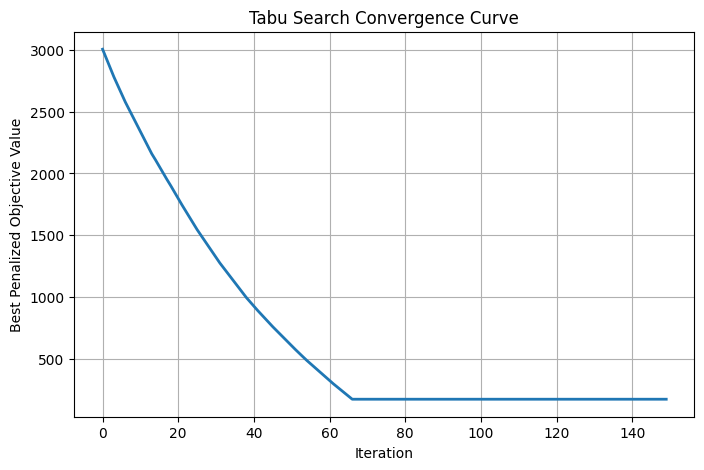

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(ts_result["convergence"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Best Penalized Objective Value")
plt.title("Tabu Search Convergence Curve")
plt.grid(True)
plt.show()

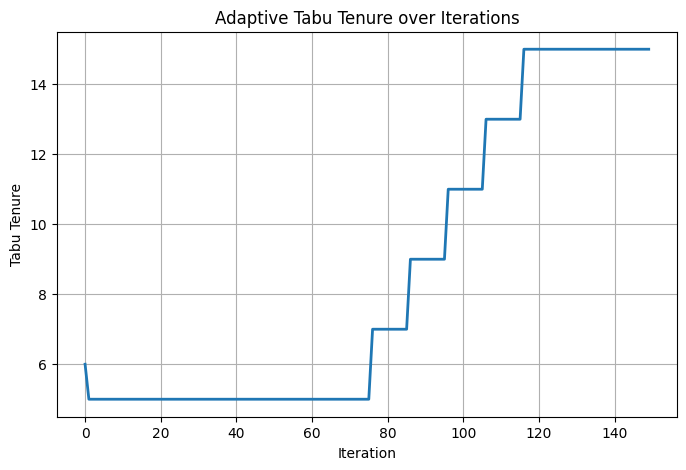

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(ts_result["tenure_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Tabu Tenure")
plt.title("Adaptive Tabu Tenure over Iterations")
plt.grid(True)
plt.show()

## 15. Hybrid Genetic Algorithm with Simulated Annealing (Hybrid GA-SA)

The third heuristic method used in this study is a **hybrid Genetic Algorithm with Simulated Annealing (Hybrid GA-SA)**.

The motivation for using this hybrid approach is that:

- the **Genetic Algorithm (GA)** is effective for **global exploration**
- **Simulated Annealing (SA)** is effective for **local exploitation**
- combining both can improve the balance between **diversification** and **intensification**

This idea is inspired by the hybrid metaheuristic strategy presented in the reference paper, where a population-based evolutionary search is strengthened by an annealing-based local improvement and solution acceptance mechanism.

For the **operator scheduling problem**, the original workflow-specific encoding in the paper is not used directly. Instead, the hybrid idea is adapted to our integer decision-vector representation:

$$
X = [x_1, x_2, \dots, x_m,\; x_1^{o}, x_2^{o}, \dots, x_m^{o},\; x_1^{p}, x_2^{p}, \dots, x_n^{p}]
$$

where:

- $x_i$ = regular peak-hour allocation for full-time operator $i$
- $x_i^{o}$ = overtime allocation for full-time operator $i$
- $x_j^{p}$ = non-peak allocation for part-time operator $j$


### 15.1 Evaluation Function

For fairness, the Hybrid GA-SA uses the same cost model and feasibility logic as the previous algorithms.

The objective is to minimize the total labor cost:

$$
f(X)=\sum_{i=1}^{m} c_i x_i + \sum_{i=1}^{m} c_i^{o} x_i^{o} + \sum_{j=1}^{n} c_j^{p} x_j^{p}
$$

subject to the staffing constraints:

$$
\sum_{i=1}^{m} x_i + \sum_{i=1}^{m} x_i^{o} \ge 4
$$

$$
\sum_{j=1}^{n} x_j^{p} \ge 2
$$

and non-negativity conditions on all decision variables.

As in the previous sections, candidate solutions are normalized or repaired so that the search remains focused on feasible or near-feasible schedules.

### 15.2 Hybrid Search Logic

The proposed Hybrid GA-SA algorithm works in three main stages within each generation:

1. **GA Exploration**
   - A population of candidate schedules is maintained.
   - Parents are selected using tournament selection.
   - Offspring are generated using crossover and mutation.

2. **SA-Based Acceptance**
   - Each offspring is compared with its parent.
   - If the offspring is better, it is accepted directly.
   - If it is worse, it may still be accepted with a probability based on temperature:
   
   $$
   P = \exp\left(-\frac{\Delta}{T}\right)
   $$
   
   where $\Delta$ is the increase in objective value and $T$ is the current temperature.

3. **Local Improvement**
   - After acceptance, a small neighborhood search is applied.
   - This local search attempts to improve the accepted solution by making small integer adjustments.


### 15.3 Neighborhood Design for Operator Scheduling

Because the operator scheduling problem is an integer allocation problem rather than a permutation scheduling problem, the neighborhood structure is adapted accordingly.

The local improvement phase uses small allocation-based moves such as:

- increasing one variable by 1
- decreasing one variable by 1
- shifting one unit from one operator to another
- replacing expensive allocations with cheaper feasible allocations where possible

These moves are suitable for refining staffing schedules while preserving the discrete nature of the problem.

### 15.4 Parameter Settings

The main parameters of the Hybrid GA-SA are:

- population size
- number of generations
- crossover probability
- mutation probability
- initial temperature
- cooling rate
- number of local search attempts per accepted solution
- tournament size

These values are chosen to provide a reasonable balance between global exploration and local refinement.

In [41]:
import numpy as np
import random
import time
import math
import pandas as pd
import matplotlib.pyplot as plt

def hybrid_random_solution():
    """
    Generate a random candidate and normalize it into a low-cost feasible form.
    """
    x = np.random.randint(low=0, high=9, size=n_var)
    return normalize_solution(x)


def hybrid_initialize_population(pop_size, seed=None):
    """
    Initialize a population of feasible candidate solutions.
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    population = []
    for _ in range(pop_size):
        population.append(hybrid_random_solution())
    return population


def hybrid_fitness(x):
    """
    Fitness function for the hybrid method.
    Lower is better.
    """
    x = normalize_solution(x)
    return compute_cost(x)

In [42]:
def tournament_selection(population, fitness_values, tournament_size=3):
    """
    Tournament selection: pick a few individuals and return the best one.
    """
    selected_indices = random.sample(range(len(population)), tournament_size)
    best_idx = min(selected_indices, key=lambda idx: fitness_values[idx])
    return population[best_idx].copy()

In [43]:
def hybrid_crossover(parent1, parent2, crossover_prob=0.9):
    """
    Single-point crossover for integer solution vectors.
    """
    p1 = parent1.copy()
    p2 = parent2.copy()

    if random.random() > crossover_prob:
        return p1, p2

    point = random.randint(1, n_var - 1)

    child1 = np.concatenate([p1[:point], p2[point:]])
    child2 = np.concatenate([p2[:point], p1[point:]])

    child1 = normalize_solution(child1)
    child2 = normalize_solution(child2)

    return child1, child2

In [44]:
def hybrid_mutation(x, mutation_prob=0.15):
    """
    Integer mutation: randomly perturb selected variables by +/-1.
    """
    child = x.copy()

    for i in range(n_var):
        if random.random() < mutation_prob:
            step = random.choice([-1, 1])
            child[i] = np.clip(child[i] + step, xl[i], xu[i])

    child = normalize_solution(child)
    return child

In [45]:
def local_improvement(x, attempts=10):
    """
    Simple local search around the accepted solution.
    Tries small integer moves and keeps the best improvement found.
    """
    best = normalize_solution(x.copy())
    best_cost = hybrid_fitness(best)

    for _ in range(attempts):
        candidate = best.copy()

        move_type = random.choice(["single_change", "shift"])

        if move_type == "single_change":
            idx = random.randint(0, n_var - 1)
            step = random.choice([-1, 1])
            candidate[idx] = np.clip(candidate[idx] + step, xl[idx], xu[idx])

        elif move_type == "shift":
            i, j = random.sample(range(n_var), 2)
            if candidate[i] > xl[i] and candidate[j] < xu[j]:
                candidate[i] -= 1
                candidate[j] += 1

        candidate = normalize_solution(candidate)
        candidate_cost = hybrid_fitness(candidate)

        if candidate_cost < best_cost:
            best = candidate
            best_cost = candidate_cost

    return best

In [46]:
def sa_acceptance(parent, child, temperature):
    """
    Simulated Annealing acceptance rule.
    """
    parent_cost = hybrid_fitness(parent)
    child_cost = hybrid_fitness(child)

    delta = child_cost - parent_cost

    if delta <= 0:
        return True

    if temperature <= 1e-12:
        return False

    prob = math.exp(-delta / temperature)
    return random.random() < prob

In [47]:
def run_hybrid_gasa(
    pop_size=60,
    n_gen=120,
    crossover_prob=0.9,
    mutation_prob=0.15,
    initial_temp=50.0,
    cooling_rate=0.95,
    local_attempts=8,
    tournament_size=3,
    seed=42
):
    """
    Hybrid Genetic Algorithm + Simulated Annealing for operator scheduling.
    """
    np.random.seed(seed)
    random.seed(seed)

    start_time = time.time()

    population = hybrid_initialize_population(pop_size, seed=seed)
    fitness_values = [hybrid_fitness(ind) for ind in population]

    best_idx = int(np.argmin(fitness_values))
    best_solution = population[best_idx].copy()
    best_cost = fitness_values[best_idx]

    convergence = []
    temperature = initial_temp

    for gen in range(n_gen):
        new_population = []

        # Elitism: keep current best
        elite_idx = int(np.argmin(fitness_values))
        elite = population[elite_idx].copy()
        new_population.append(elite)

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, fitness_values, tournament_size)
            parent2 = tournament_selection(population, fitness_values, tournament_size)

            child1, child2 = hybrid_crossover(parent1, parent2, crossover_prob=crossover_prob)

            child1 = hybrid_mutation(child1, mutation_prob=mutation_prob)
            child2 = hybrid_mutation(child2, mutation_prob=mutation_prob)

            # SA-style acceptance against parent1 and parent2
            accepted1 = child1 if sa_acceptance(parent1, child1, temperature) else parent1
            accepted2 = child2 if sa_acceptance(parent2, child2, temperature) else parent2

            # Local improvement after acceptance
            accepted1 = local_improvement(accepted1, attempts=local_attempts)
            accepted2 = local_improvement(accepted2, attempts=local_attempts)

            new_population.append(accepted1)
            if len(new_population) < pop_size:
                new_population.append(accepted2)

        population = [normalize_solution(ind) for ind in new_population]
        fitness_values = [hybrid_fitness(ind) for ind in population]

        gen_best_idx = int(np.argmin(fitness_values))
        gen_best_solution = population[gen_best_idx].copy()
        gen_best_cost = fitness_values[gen_best_idx]

        if gen_best_cost < best_cost:
            best_cost = gen_best_cost
            best_solution = gen_best_solution.copy()

        convergence.append(best_cost)

        # Cooling
        temperature *= cooling_rate

    runtime = time.time() - start_time

    regular, overtime, part_time = decode_solution(best_solution)
    peak_coverage = int(np.sum(regular) + np.sum(overtime))
    nonpeak_coverage = int(np.sum(part_time))

    return {
        "best_solution": best_solution,
        "best_cost": best_cost,
        "regular": regular,
        "overtime": overtime,
        "part_time": part_time,
        "peak_coverage": peak_coverage,
        "nonpeak_coverage": nonpeak_coverage,
        "feasible": is_feasible(best_solution),
        "runtime": runtime,
        "convergence": convergence,
        "parameters": {
            "pop_size": pop_size,
            "n_gen": n_gen,
            "crossover_prob": crossover_prob,
            "mutation_prob": mutation_prob,
            "initial_temp": initial_temp,
            "cooling_rate": cooling_rate,
            "local_attempts": local_attempts,
            "tournament_size": tournament_size,
            "seed": seed
        }
    }

In [48]:
hybrid_result = run_hybrid_gasa(
    pop_size=60,
    n_gen=120,
    crossover_prob=0.90,
    mutation_prob=0.15,
    initial_temp=50.0,
    cooling_rate=0.95,
    local_attempts=8,
    tournament_size=3,
    seed=42
)

print("Best Hybrid GA-SA solution vector:")
print(hybrid_result["best_solution"])

print("\nRegular full-time allocations:", hybrid_result["regular"])
print("Overtime allocations:", hybrid_result["overtime"])
print("Part-time allocations:", hybrid_result["part_time"])

print("\nBest Hybrid GA-SA cost:", hybrid_result["best_cost"])
print("Peak-hour coverage:", hybrid_result["peak_coverage"])
print("Non-peak-hour coverage:", hybrid_result["nonpeak_coverage"])
print("Feasible solution:", hybrid_result["feasible"])
print("Runtime (s):", round(hybrid_result["runtime"], 4))

Best Hybrid GA-SA solution vector:
[4 0 0 0 0 0 0 0 0 0 2 0 0 0 0]

Regular full-time allocations: [4 0 0 0 0]
Overtime allocations: [0 0 0 0 0]
Part-time allocations: [2 0 0 0 0]

Best Hybrid GA-SA cost: 170.0
Peak-hour coverage: 4
Non-peak-hour coverage: 2
Feasible solution: True
Runtime (s): 9.2844


In [49]:
hybrid_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        hybrid_result["best_cost"],
        hybrid_result["peak_coverage"],
        hybrid_result["nonpeak_coverage"],
        hybrid_result["feasible"],
        hybrid_result["runtime"]
    ]
})

hybrid_summary

,Component,Value
0,Best Cost,170.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),9.284368


### 15.5 Convergence Plot

The following plot shows the best objective value found by the Hybrid GA-SA over generations.

A decreasing curve indicates that the hybrid method is successfully improving the staffing schedule over time through the combined effects of population search, annealing-based acceptance, and local improvement.

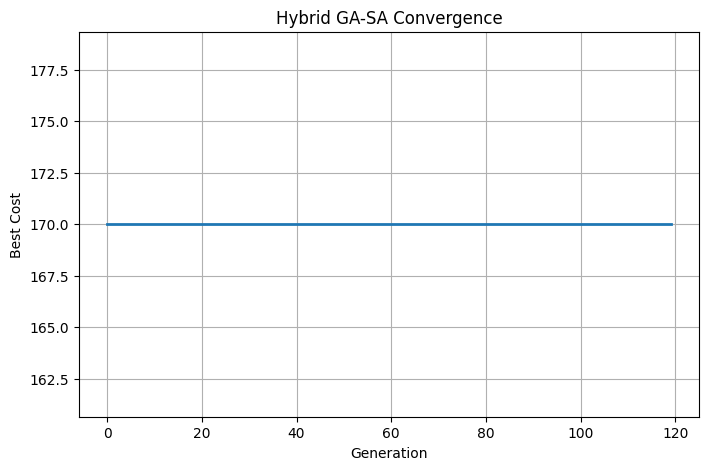

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_result["convergence"], linewidth=2)
plt.xlabel("Generation")
plt.ylabel("Best Cost")
plt.title("Hybrid GA-SA Convergence")
plt.grid(True)
plt.show()

### 15.6 Interpretation of the Hybrid Result

The Hybrid GA-SA produces a feasible staffing schedule while combining two complementary search mechanisms:

- **GA operators** promote broader search across the solution space
- **SA acceptance** allows controlled acceptance of non-improving solutions
- **local improvement** refines accepted solutions through small neighborhood moves



## 16. Experimental Setup

This section defines the experimental setup used to compare the three heuristic methods for the operator scheduling problem:

1. Genetic Algorithm (GA)
2. Tabu Search (TS)
3. Hybrid Genetic Algorithm with Simulated Annealing (Hybrid GA-SA)

The purpose of this section is to ensure that the comparison is fair, repeatable, and consistent with the assignment requirements. In particular, the experiments are designed to support later analysis using descriptive statistics, runtime comparisons, convergence plots, and statistical tests such as Wilcoxon and Friedman tests.

### 16.1 Experimental Objectives

The experiments are designed to evaluate the algorithms in terms of:

- solution quality (minimum labor cost)
- feasibility of generated schedules
- robustness across repeated runs
- computational time
- convergence behavior

The assignment requires a comparative study supported by statistical indicators such as Min, Average, Median, and Standard Deviation, along with computational and statistical analysis. Therefore, all algorithms will be executed multiple times under the same general conditions.

### 16.2 Comparison Protocol

To make the comparison fair:

- all three algorithms use the same objective function
- all three algorithms use the same feasibility rules and repair/normalization logic
- the same problem data are used for every run
- each algorithm is executed multiple times with different random seeds
- the same performance indicators are collected from each run

For each run, the following outputs are recorded:

- best objective value
- feasibility status
- runtime
- peak-hour coverage
- non-peak-hour coverage
- convergence history

### 16.3 Number of Runs

Because heuristic algorithms are stochastic, a single run is not sufficient to evaluate performance reliably.

Therefore, each algorithm will be run multiple times using different random seeds. This allows us to measure:

- minimum performance
- average performance
- median performance
- standard deviation
- consistency across runs

In this study, the default experimental setting uses **30 independent runs** for each algorithm. This is sufficient for meaningful descriptive and non-parametric statistical analysis.

### 16.3 Number of Runs

Because heuristic algorithms are stochastic, a single run is not sufficient to evaluate performance reliably.

Therefore, each algorithm will be run multiple times using different random seeds. This allows us to measure:

- minimum performance
- average performance
- median performance
- standard deviation
- consistency across runs

In this study, the default experimental setting uses **30 independent runs** for each algorithm. This is sufficient for meaningful descriptive and non-parametric statistical analysis.

### 16.4 Performance Measures

The following measures are collected for each algorithm:

#### Solution Quality
- Best cost found in each run

#### Statistical Indicators
- Minimum (Min)
- Average (Ave.)
- Median (Med.)
- Standard Deviation (Std.)

#### Computational Performance
- Runtime per run
- Average runtime

#### Feasibility Measures
- Peak-hour coverage
- Non-peak-hour coverage
- Feasibility rate

#### Dynamic Behavior
- Convergence curve over iterations/generations

These measures will later support both descriptive comparison and statistical testing.

### 16.5 Experimental Parameters

The algorithms are executed using fixed baseline parameter settings in the main comparison phase.

Later sections will vary selected parameters for sensitivity analysis. For now, the baseline settings are chosen to provide a reasonable balance between search depth and computational effort.

### 16.6 Reproducibility

To improve reproducibility, each run is associated with a fixed random seed. The seed list is shared across all algorithms so that the repeated experiments are performed under comparable random conditions.

In [52]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

In [53]:
# Experimental configuration
N_RUNS = 30
SEEDS = list(range(1, N_RUNS + 1))

experiment_config = {
    "n_runs": N_RUNS,
    "seeds": SEEDS
}

experiment_config

{'n_runs': 30,
 'seeds': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30]}

In [54]:
def summarize_results(values):
    """
    Compute descriptive statistics for a list/array of values.
    """
    arr = np.array(values, dtype=float)
    return {
        "Min": np.min(arr),
        "Ave": np.mean(arr),
        "Med": np.median(arr),
        "Std": np.std(arr, ddof=1) if len(arr) > 1 else 0.0,
        "Max": np.max(arr)
    }

In [55]:
def extract_run_record(result, algorithm_name, run_id, seed):
    """
    Convert one algorithm result into a flat experimental record.
    """
    return {
        "Algorithm": algorithm_name,
        "Run": run_id,
        "Seed": seed,
        "BestCost": result["best_cost"],
        "Feasible": result["feasible"],
        "PeakCoverage": result["peak_coverage"],
        "NonPeakCoverage": result["nonpeak_coverage"],
        "Runtime": result["runtime"]
    }

### 16.7 Unified Execution Framework

To compare the algorithms efficiently, a unified execution framework is used. Each algorithm is wrapped so that it returns results in the same structure. This ensures that later statistical analysis can be carried out consistently.

In [60]:
# -------------------------------------------------------------------
# IMPORTANT:
# Replace the function calls below with your actual GA and TS function names
# if they are different in your notebook.
# -------------------------------------------------------------------

def run_ga_wrapper(seed):
    """
    Wrapper for Genetic Algorithm.
    Replace run_ga(...) with your actual GA function if needed.
    Must return a dictionary with keys:
    best_cost, feasible, peak_coverage, nonpeak_coverage, runtime, convergence
    """
    result = run_adaptive_ga(seed=seed)   # <-- change if needed
    return result


def run_ts_wrapper(seed):
    """
    Wrapper for Tabu Search.
    Replace run_tabu_search(...) with your actual TS function if needed.
    Must return a dictionary with keys:
    best_cost, feasible, peak_coverage, nonpeak_coverage, runtime, convergence
    """
    result = run_tabu_search(seed=seed)   # <-- change if needed
    return result


def run_hybrid_wrapper(seed):
    """
    Wrapper for Hybrid GA-SA.
    """
    result = run_hybrid_gasa(seed=seed)
    return result

In [61]:
def run_experiments(seeds):
    """
    Run all algorithms over all seeds and collect results.
    """
    all_records = []
    all_histories = {
        "GA": [],
        "TS": [],
        "Hybrid GA-SA": []
    }

    for run_id, seed in enumerate(seeds, start=1):
        # GA
        ga_result = run_ga_wrapper(seed)
        all_records.append(extract_run_record(ga_result, "GA", run_id, seed))
        all_histories["GA"].append(ga_result["convergence"])

        # TS
        ts_result = run_ts_wrapper(seed)
        all_records.append(extract_run_record(ts_result, "TS", run_id, seed))
        all_histories["TS"].append(ts_result["convergence"])

        # Hybrid
        hy_result = run_hybrid_wrapper(seed)
        all_records.append(extract_run_record(hy_result, "Hybrid GA-SA", run_id, seed))
        all_histories["Hybrid GA-SA"].append(hy_result["convergence"])

    results_df = pd.DataFrame(all_records)
    return results_df, all_histories

In [65]:
results_df, all_histories = run_experiments(SEEDS)
results_df.head()

,Algorithm,Run,Seed,BestCost,Feasible,PeakCoverage,NonPeakCoverage,Runtime
0,GA,1,1,170.0,True,4,2,7.007401
1,TS,1,1,170.0,True,4,2,0.154585
2,Hybrid GA-SA,1,1,170.0,True,4,2,8.526198
3,GA,2,2,170.0,True,4,2,6.843045
4,TS,2,2,170.0,True,4,2,0.171792


In [66]:
def build_summary_table(results_df):
    """
    Build summary statistics table for each algorithm.
    """
    rows = []

    for algo in results_df["Algorithm"].unique():
        subset = results_df[results_df["Algorithm"] == algo]

        cost_stats = summarize_results(subset["BestCost"])
        runtime_stats = summarize_results(subset["Runtime"])

        feasibility_rate = 100 * subset["Feasible"].mean()

        rows.append({
            "Algorithm": algo,
            "Cost Min": cost_stats["Min"],
            "Cost Ave": cost_stats["Ave"],
            "Cost Med": cost_stats["Med"],
            "Cost Std": cost_stats["Std"],
            "Cost Max": cost_stats["Max"],
            "Runtime Ave (s)": runtime_stats["Ave"],
            "Runtime Std (s)": runtime_stats["Std"],
            "Feasibility Rate (%)": feasibility_rate
        })

    return pd.DataFrame(rows).sort_values(by="Cost Ave").reset_index(drop=True)

In [67]:
summary_table = build_summary_table(results_df)
summary_table

,Algorithm,Cost Min,Cost Ave,Cost Med,Cost Std,Cost Max,Runtime Ave (s),Runtime Std (s),Feasibility Rate (%)
0,GA,170.0,170.0,170.0,0.00000,170.0,6.350610,0.682479,100.0
1,Hybrid GA-SA,170.0,170.0,170.0,0.00000,170.0,9.003736,0.631241,100.0
2,TS,170.0,170.9,170.0,2.38313,182.0,0.169124,0.042727,100.0


### 16.8 Initial Experimental Output

The following table reports the initial descriptive statistics across repeated runs for each algorithm.

At this stage, the table provides an overall view of:

- average solution quality
- variability of performance
- runtime behavior
- feasibility consistency

A more detailed interpretation will be presented in the results and discussion section.

In [68]:
results_df

,Algorithm,Run,Seed,BestCost,Feasible,PeakCoverage,NonPeakCoverage,Runtime
0,GA,1,1,170.0,True,4,2,7.007401
1,TS,1,1,170.0,True,4,2,0.154585
2,Hybrid GA-SA,1,1,170.0,True,4,2,8.526198
3,GA,2,2,170.0,True,4,2,6.843045
4,TS,2,2,170.0,True,4,2,0.171792
...,...,...,...,...,...,...,...,...
85,TS,29,29,170.0,True,4,2,0.147685
86,Hybrid GA-SA,29,29,170.0,True,4,2,8.456527
87,GA,30,30,170.0,True,4,2,6.821717
88,TS,30,30,170.0,True,4,2,0.151064


### 16.9 Average Convergence Curves

Since the algorithms are stochastic, a single convergence curve may not represent their typical behavior.

Therefore, the average convergence curve across repeated runs is used to show the general optimization trend of each method.

In [69]:
def average_convergence(histories):
    """
    Average convergence histories across runs.
    Assumes equal-length histories for each algorithm.
    """
    max_len = max(len(h) for h in histories)
    arr = np.array(histories, dtype=float)
    return np.mean(arr, axis=0)

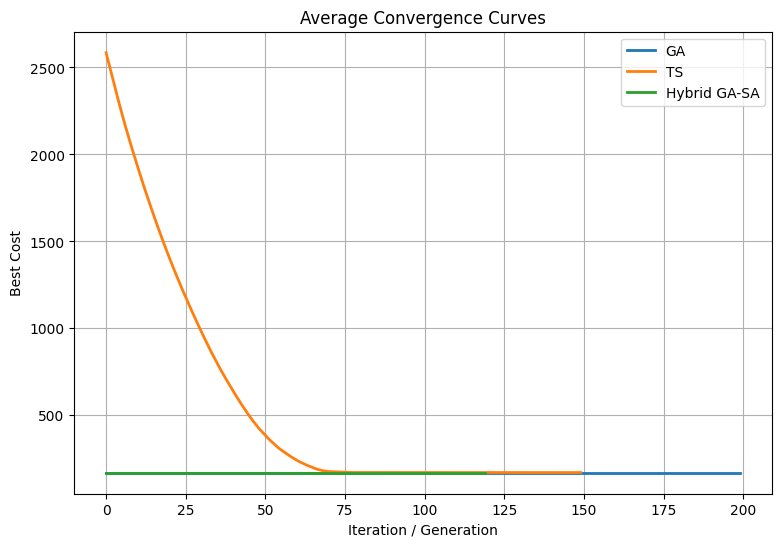

In [70]:
plt.figure(figsize=(9, 6))

for algo, histories in all_histories.items():
    avg_curve = average_convergence(histories)
    plt.plot(avg_curve, label=algo, linewidth=2)

plt.xlabel("Iteration / Generation")
plt.ylabel("Best Cost")
plt.title("Average Convergence Curves")
plt.legend()
plt.grid(True)
plt.show()

### 16.10 Notes on the Experimental Setup

This experimental setup establishes the baseline framework for later sections of the notebook. The next steps will use these repeated-run results to perform:

- detailed comparative discussion
- Wilcoxon rank-sum tests
- Friedman ranking test
- sensitivity analysis
- scalability analysis
- ablation study for the hybrid algorithm

Thus, this section serves as the foundation for the full empirical evaluation required in the assignment.

In [95]:
result = run_adaptive_ga(seed=seed)
result = run_tabu_search(seed=seed)
Result = run_hybrid_gasa(seed=seed)

## 17. Statistical Analysis

This section presents the statistical analysis of the repeated experimental results obtained for the three algorithms:

1. Genetic Algorithm (GA)
2. Tabu Search (TS)
3. Hybrid Genetic Algorithm with Simulated Annealing (Hybrid GA-SA)

The purpose of this section is to compare the algorithms not only by average performance, but also by statistical consistency and significance of performance differences.

In accordance with the assignment requirements, the analysis includes:

- descriptive statistics such as Minimum, Average, Median, and Standard Deviation
- pairwise non-parametric statistical testing using the Wilcoxon Rank-Sum Test
- overall ranking comparison using the Friedman Ranking Test

Because heuristic algorithms are stochastic, statistical testing is necessary to determine whether the observed differences in solution quality are meaningful rather than due to random variation.

### 17.1 Descriptive Statistics

The first step is to summarize the repeated-run results using standard descriptive statistics.

For each algorithm, the following indicators are computed from the best cost values over all runs:

- Minimum (Min)
- Average (Ave.)
- Median (Med.)
- Standard Deviation (Std.)
- Maximum (Max)

These values provide an initial view of solution quality and robustness.

In [98]:
cost_stats_table = results_df.groupby("Algorithm")["BestCost"].agg(
    Min="min",
    Ave="mean",
    Med="median",
    Std="std",
    Max="max"
).reset_index().sort_values(by="Ave")

cost_stats_table

,Algorithm,Min,Ave,Med,Std,Max
0,GA,170.0,170.0,170.0,0.00000,170.0
1,Hybrid GA-SA,170.0,170.0,170.0,0.00000,170.0
2,TS,170.0,170.9,170.0,2.38313,182.0


### 17.2 Runtime Statistics

In addition to solution quality, computational performance is also important.

The following table summarizes runtime statistics for each algorithm across repeated runs.

In [99]:
runtime_stats_table = results_df.groupby("Algorithm")["Runtime"].agg(
    Min="min",
    Ave="mean",
    Med="median",
    Std="std",
    Max="max"
).reset_index().sort_values(by="Ave")

runtime_stats_table

,Algorithm,Min,Ave,Med,Std,Max
2,TS,0.137513,0.169124,0.151411,0.042727,0.307489
0,GA,5.461951,6.350610,6.571267,0.682479,7.369931
1,Hybrid GA-SA,7.902411,9.003736,9.237145,0.631241,9.829242


### 17.3 Feasibility Analysis

Since the operator scheduling problem is constrained, it is also necessary to verify whether the algorithms consistently generate feasible staffing schedules.

The following table reports the feasibility rate for each algorithm.

In [100]:
feasibility_table = results_df.groupby("Algorithm")["Feasible"].mean().reset_index()
feasibility_table["Feasibility Rate (%)"] = 100 * feasibility_table["Feasible"]
feasibility_table = feasibility_table.drop(columns=["Feasible"])

feasibility_table

,Algorithm,Feasibility Rate (%)
0,GA,100.0
1,Hybrid GA-SA,100.0
2,TS,100.0


### 17.4 Wilcoxon Rank-Sum Test

To compare algorithms pairwise, a non-parametric Wilcoxon-based test is used.

Because the algorithms are stochastic and normality cannot be assumed, a non-parametric test is more appropriate than a parametric t-test.

The Wilcoxon test is applied pairwise to the best-cost results of:

- GA vs TS
- GA vs Hybrid GA-SA
- TS vs Hybrid GA-SA

The null hypothesis is that the two algorithms have no significant difference in performance distribution.

A p-value smaller than 0.05 indicates a statistically significant difference at the 5% significance level.

In [101]:
from scipy.stats import ranksums

In [102]:
def wilcoxon_rank_sum_table(results_df):
    pairs = [
        ("GA", "TS"),
        ("GA", "Hybrid GA-SA"),
        ("TS", "Hybrid GA-SA")
    ]

    rows = []

    for a1, a2 in pairs:
        x = results_df.loc[results_df["Algorithm"] == a1, "BestCost"].values
        y = results_df.loc[results_df["Algorithm"] == a2, "BestCost"].values

        stat, p = ranksums(x, y)

        rows.append({
            "Comparison": f"{a1} vs {a2}",
            "Statistic": stat,
            "p-value": p,
            "Significant at 0.05?": "Yes" if p < 0.05 else "No"
        })

    return pd.DataFrame(rows)

In [103]:
wilcoxon_table = wilcoxon_rank_sum_table(results_df)
wilcoxon_table

,Comparison,Statistic,p-value,Significant at 0.05?
0,GA vs TS,-1.552365,0.120575,No
1,GA vs Hybrid GA-SA,0.000000,1.000000,No
2,TS vs Hybrid GA-SA,1.552365,0.120575,No


### 17.5 Friedman Ranking Test

While the Wilcoxon test compares algorithms pairwise, the Friedman test compares all algorithms simultaneously.

This test is useful when multiple algorithms are evaluated over repeated runs and a ranking-based comparison is needed.

The null hypothesis is that all algorithms perform equivalently.

A p-value smaller than 0.05 indicates that at least one algorithm performs significantly differently from the others.

In [104]:
from scipy.stats import friedmanchisquare

In [105]:
ga_costs = results_df.loc[results_df["Algorithm"] == "GA", "BestCost"].values
ts_costs = results_df.loc[results_df["Algorithm"] == "TS", "BestCost"].values
hy_costs = results_df.loc[results_df["Algorithm"] == "Hybrid GA-SA", "BestCost"].values

friedman_stat, friedman_p = friedmanchisquare(ga_costs, ts_costs, hy_costs)

friedman_results = pd.DataFrame([{
    "Friedman Statistic": friedman_stat,
    "p-value": friedman_p,
    "Significant at 0.05?": "Yes" if friedman_p < 0.05 else "No"
}])

friedman_results

,Friedman Statistic,p-value,Significant at 0.05?
0,14.0,0.000912,Yes


### 17.6 Mean Rank Comparison

To support interpretation of the Friedman test, the average rank of each algorithm is also computed.

Since lower cost is better, the algorithm with the lowest average rank is considered the strongest performer.

In [106]:
from scipy.stats import rankdata

In [107]:
rank_matrix = []

for i in range(N_RUNS):
    run_subset = results_df[results_df["Run"] == (i + 1)].copy()
    run_subset = run_subset.set_index("Algorithm").loc[["GA", "TS", "Hybrid GA-SA"]]

    costs = run_subset["BestCost"].values
    ranks = rankdata(costs, method="average")  # lower cost gets lower rank
    rank_matrix.append(ranks)

rank_matrix = np.array(rank_matrix)

mean_ranks = pd.DataFrame({
    "Algorithm": ["GA", "TS", "Hybrid GA-SA"],
    "Mean Rank": rank_matrix.mean(axis=0)
}).sort_values(by="Mean Rank")

mean_ranks

,Algorithm,Mean Rank
0,GA,1.883333
2,Hybrid GA-SA,1.883333
1,TS,2.233333


### 17.7 Interpretation of Statistical Results

The descriptive statistics show how the algorithms compare in terms of solution quality, variability, and runtime.

The Wilcoxon tests show whether the pairwise differences are statistically significant, while the Friedman test evaluates whether the overall differences among all three algorithms are significant.

Finally, the mean-rank table provides a ranking-based interpretation of the relative performance of the algorithms.

Together, these results provide the statistical evidence required for a rigorous comparative study.

In [108]:
best_avg_algo = cost_stats_table.sort_values("Ave").iloc[0]["Algorithm"]
best_runtime_algo = runtime_stats_table.sort_values("Ave").iloc[0]["Algorithm"]
best_rank_algo = mean_ranks.iloc[0]["Algorithm"]

print(f"Best average solution quality: {best_avg_algo}")
print(f"Fastest average runtime: {best_runtime_algo}")
print(f"Best Friedman mean rank: {best_rank_algo}")

Best average solution quality: GA
Fastest average runtime: TS
Best Friedman mean rank: GA


In [110]:
from scipy.stats import wilcoxon

def wilcoxon_signed_table(results_df):
    pairs = [
        ("GA", "TS"),
        ("GA", "Hybrid GA-SA"),
        ("TS", "Hybrid GA-SA")
    ]

    rows = []

    for a1, a2 in pairs:
        x = results_df.loc[results_df["Algorithm"] == a1, "BestCost"].values
        y = results_df.loc[results_df["Algorithm"] == a2, "BestCost"].values

        stat, p = wilcoxon(x, y)

        rows.append({
            "Comparison": f"{a1} vs {a2}",
            "Statistic": stat,
            "p-value": p,
            "Significant at 0.05?": "Yes" if p < 0.05 else "No"
        })

    return pd.DataFrame(rows)

In [111]:
wilcoxon_signed_results = wilcoxon_signed_table(results_df)
wilcoxon_signed_results

/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,Comparison,Statistic,p-value,Significant at 0.05?
0,GA vs TS,0.0,0.014059,Yes
1,GA vs Hybrid GA-SA,0.0,NaN,No
2,TS vs Hybrid GA-SA,0.0,0.014059,Yes


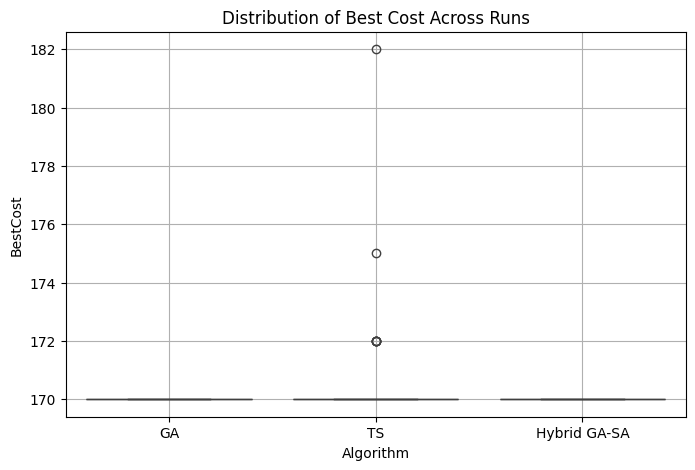

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=all_runs_df, x="Algorithm", y="BestCost")
plt.title("Distribution of Best Cost Across Runs")
plt.grid(True)
plt.show()

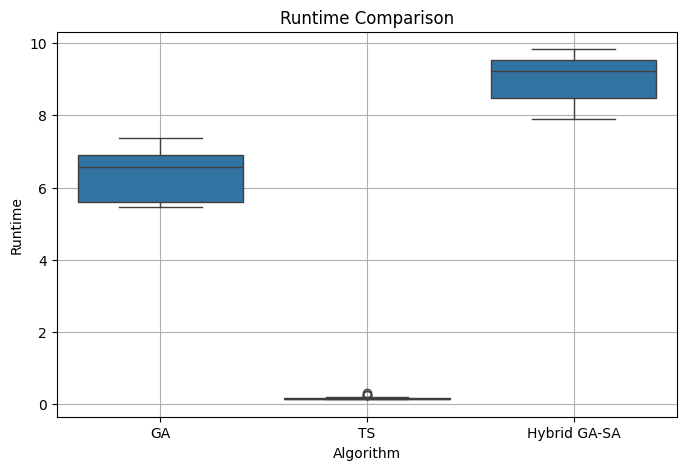

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(data=all_runs_df, x="Algorithm", y="Runtime")
plt.title("Runtime Comparison")
plt.grid(True)
plt.show()